In [1]:
import numpy as np
import pandas as pd
from aeon.anomaly_detection.series.distance_based import LOF
from sklearn.metrics import f1_score, classification_report
from utils.evaluation import evaluate_model, cross_validate
from utils.data_loader import load_volvo, load_optuna_val
from utils.evaluation import cross_validate
from utils.hyperparameter_search import run_optuna_study

result_path="../Results/Volvo LOF"

D:\Programming things\Examensarbete\Examensarbete 2.0\Exjobb-Gitrepo\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train, y_train, X_test, y_test, timestamps_train, timestamps_test, df_train, df_test = load_volvo(
    "../Dataset/volvoTrain.csv",
    "../Dataset/volvoTest.csv"
)

In [3]:
hyperparameters = {
    "n_neighbors": ("int", 10, 40, False),
}

df_train_optuna = load_optuna_val(df_train)

study = run_optuna_study(
    model_class=LOF,
    hyperparameters=hyperparameters,
    train_df=df_train_optuna,
    validation_ratio=0.20,
    n_trials=10,
    study_name="Final_LOF_optuna_study",
    storage="sqlite:///Final_LOFTest_optuna.db"
)

print("Best params:", study.best_params)
print("Best validation score:", study.best_value)
print("Best trial extra metrics:", study.best_trial.user_attrs)

Best params: {'n_neighbors': 39}
Best validation score: 0.9761904761904762
Best trial extra metrics: {'pr_auc': 0.9761904761904762}


In [4]:
best_params = study.best_params

static_params = {
    "window_size": 50,
    "stride": 5,
    "n_jobs": 1,
}

params = best_params | static_params

In [5]:
model = LOF(**params)
scores_test = model.fit_predict(X_test, axis=0)

In [6]:
cross_val_scores = cross_validate(train_df=df_train, model=LOF, params=params, result_path=result_path)
print(cross_val_scores)

{'fold1_roc_auc': 0.9992782553709441, 'fold1_pr_auc': 0.287834937779391, 'fold2_roc_auc': 0.9999941179345082, 'fold2_pr_auc': 0.8456190476190476, 'mean_threshold': 9.631981705198285}


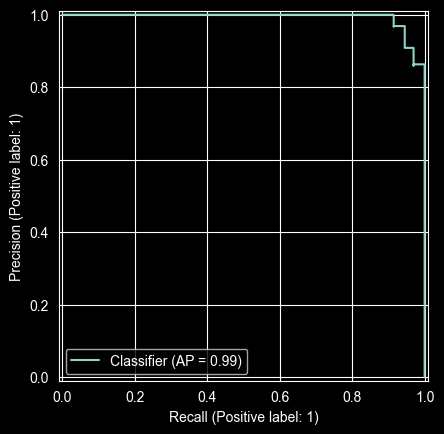

In [7]:
threshold = cross_val_scores["mean_threshold"]
evaluate_model(y_test, scores_test, threshold=threshold, result_path=result_path)

In [8]:
import pandas as pd
import os
df = pd.DataFrame(scores_test, columns=["score"])
scores_path = os.path.join(result_path, "scores.csv")
df.to_csv(scores_path, index = False)